# 01 — Uticaj veličine Faster-Whisper modela na brzinu i tačnost transkripcije

## Cilj eksperimenta

Cilj eksperimenta je analiza uticaja veličine Faster-Whisper modela na brzinu i tačnost automatskog prepoznavanja govora na srpskom jeziku.

Poređene su četiri veličine modela: `tiny`, `base`, `small` i `medium`. Svi modeli izvršavaju se na CPU-u korišćenjem INT8 kvantizacije, čime se omogućava da veličina modela predstavlja glavnu promenljivu eksperimenta.

Za evaluaciju je korišćeno 20 reprezentativnih prirodnih audio zapisa raspoređenih u četiri grupe prema trajanju: kratki, srednji, dugi i veoma dugi. Skup obuhvata sva tri govornika iz osnovnog benchmark skupa.

Performanse se analiziraju pomoću vremena transkripcije, Real-Time Factor (RTF) i Word Error Rate (WER) metrike, sa ciljem određivanja kompromisa između brzine izvršavanja i kvaliteta transkripcije.


In [1]:
from pathlib import Path

# Automatski pronalazak root foldera projekta.
# Radi ako je notebook pokrenut iz notebooks/ ili iz root foldera projekta.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Novi skup sa 40 prirodnih srpskih snimaka
AUDIO_DIR = PROJECT_ROOT / "audio" / "40Sentences00-08Notebooks"

# Poseban folder za rezultate eksperimenta 01
REZULTATI_DIR = PROJECT_ROOT / "rezultati" / "01_uticaj_velicine_modela"
REZULTATI_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("AUDIO_DIR:", AUDIO_DIR)
print("REZULTATI_DIR:", REZULTATI_DIR)

PROJECT_ROOT: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR
AUDIO_DIR: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\audio\40Sentences00-08Notebooks
REZULTATI_DIR: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\01_uticaj_velicine_modela


In [2]:
# ============================================================
# 20 REPREZENTATIVNIH PRIRODNIH SRPSKIH AUDIO SNIMAKA
#
# kratki:       1-5
# srednji:     11-15
# dugi:        26-30
# veoma dugi:  36-40
# ============================================================

test_set = [
    {
        "broj": 1,
        "audio": AUDIO_DIR / "1govornik1.wav",
        "govornik": "govornik1",
        "grupa": "kratki",
        "ref": "Veštačka inteligencija omogućava računarima da rešavaju složene probleme i analiziraju velike količine podataka."
    },
    {
        "broj": 2,
        "audio": AUDIO_DIR / "2govornik1.wav",
        "govornik": "govornik1",
        "grupa": "kratki",
        "ref": "Automatsko prepoznavanje govora pretvara izgovorene reči u tekst koji računar može dalje da obrađuje."
    },
    {
        "broj": 3,
        "audio": AUDIO_DIR / "3govornik1.wav",
        "govornik": "govornik1",
        "grupa": "kratki",
        "ref": "Danas je veoma prijatan dan, pa smo odlučili da prošetamo kroz centar grada posle ručka."
    },
    {
        "broj": 4,
        "audio": AUDIO_DIR / "4govornik1.wav",
        "govornik": "govornik1",
        "grupa": "kratki",
        "ref": "Novi računari imaju brže procesore, više memorije i znatno bolje performanse nego prethodne generacije."
    },
    {
        "broj": 5,
        "audio": AUDIO_DIR / "5govornik2.wav",
        "govornik": "govornik2",
        "grupa": "kratki",
        "ref": "Mašinsko učenje koristi podatke kako bi model naučio da prepoznaje obrasce i donosi odgovarajuće odluke."
    },
    {
        "broj": 11,
        "audio": AUDIO_DIR / "11govornik1.wav",
        "govornik": "govornik1",
        "grupa": "srednji",
        "ref": "Savremeni sistemi za automatsko prepoznavanje govora koriste duboke neuronske mreže kako bi analizirali zvučni signal i pretvorili ga u tekst. Njihova tačnost zavisi od modela, kvaliteta snimka, jezika i karakteristika govornika."
    },
    {
        "broj": 12,
        "audio": AUDIO_DIR / "12govornik1.wav",
        "govornik": "govornik1",
        "grupa": "srednji",
        "ref": "Juče sam krenuo do grada nešto ranije nego obično. Na ulicama nije bilo mnogo ljudi, pa sam brzo završio sve obaveze. Nakon toga sam seo u obližnji kafić i sačekao prijatelja."
    },
    {
        "broj": 13,
        "audio": AUDIO_DIR / "13govornik1.wav",
        "govornik": "govornik1",
        "grupa": "srednji",
        "ref": "Whisper je model za automatsko prepoznavanje govora koji može da radi sa velikim brojem jezika. Faster-Whisper koristi optimizovanu implementaciju koja omogućava efikasnije izvršavanje i manju potrošnju računarskih resursa."
    },
    {
        "broj": 14,
        "audio": AUDIO_DIR / "14govornik1.wav",
        "govornik": "govornik1",
        "grupa": "srednji",
        "ref": "Kada razgovaramo u tihoj prostoriji, sistem uglavnom može veoma jasno da prepozna izgovorene reči. Međutim, saobraćaj, muzika, razgovor drugih ljudi i različiti izvori šuma mogu značajno da otežaju transkripciju."
    },
    {
        "broj": 15,
        "audio": AUDIO_DIR / "15govornik1.wav",
        "govornik": "govornik1",
        "grupa": "srednji",
        "ref": "Tokom razvoja softverske aplikacije programeri prvo analiziraju zahteve korisnika, zatim projektuju sistem i implementiraju potrebne funkcionalnosti. Nakon toga slede testiranje, ispravljanje grešaka i postavljanje aplikacije u produkciono okruženje."
    },
    {
        "broj": 26,
        "audio": AUDIO_DIR / "26govornik1.wav",
        "govornik": "govornik1",
        "grupa": "dugi",
        "ref": "Automatsko prepoznavanje govora predstavlja oblast veštačke inteligencije koja se bavi pretvaranjem zvučnog signala u tekst. Savremeni sistemi koriste modele dubokog učenja koji mogu da analiziraju kompleksne karakteristike ljudskog govora. Njihove performanse mogu da zavise od jezika, kvaliteta mikrofona, prisustva pozadinskog šuma, brzine govora i karakteristika samog govornika. Zbog toga je prilikom evaluacije važno koristiti različite vrste zvučnih zapisa."
    },
    {
        "broj": 27,
        "audio": AUDIO_DIR / "27govornik1.wav",
        "govornik": "govornik1",
        "grupa": "dugi",
        "ref": "Jednog jutra krenuo sam automobilom prema gradu nešto ranije nego obično. Saobraćaj je u početku bio veoma slab, ali se približavanjem centru broj vozila postepeno povećavao. Dok sam čekao na semaforu, na radiju su govorili o vremenskoj prognozi za narednih nekoliko dana. Najavljeno je sunčano vreme, ali i mogućnost kratkotrajne kiše tokom vikenda. Kada sam stigao, parkirao sam automobil i nastavio pešice."
    },
    {
        "broj": 28,
        "audio": AUDIO_DIR / "28govornik1.wav",
        "govornik": "govornik1",
        "grupa": "dugi",
        "ref": "Whisper postoji u više veličina modela, od veoma malih do znatno većih modela. Manji modeli zahtevaju manje memorije i uglavnom omogućavaju bržu transkripciju, dok veći modeli mogu da pruže veću tačnost u zahtevnijim uslovima. Zbog toga izbor modela predstavlja kompromis između kvaliteta transkripcije i potrebnih računarskih resursa. Taj kompromis je posebno važan kada se sistem izvršava na običnom računaru bez snažne grafičke kartice."
    },
    {
        "broj": 29,
        "audio": AUDIO_DIR / "29govornik2.wav",
        "govornik": "govornik2",
        "grupa": "dugi",
        "ref": "Pozadinski šum predstavlja jedan od najčešćih problema kod sistema za automatsko prepoznavanje govora. U realnom okruženju mikrofon ne snima samo glas osobe već i zvuk automobila, ventilatora, drugih ljudi ili muzike. Ako je govor dovoljno snažan u odnosu na šum, transkripcija može ostati veoma dobra. Međutim, kada se odnos signala i šuma smanjuje, broj pogrešno prepoznatih reči uglavnom počinje da raste."
    },
    {
        "broj": 30,
        "audio": AUDIO_DIR / "30govornik2.wav",
        "govornik": "govornik2",
        "grupa": "dugi",
        "ref": "Kada razvijamo sistem koji treba da radi u realnom vremenu, nije dovoljno posmatrati samo njegovu tačnost. Potrebno je analizirati koliko vremena modelu treba da obradi određenu količinu zvuka. Ako obrada pet sekundi govora traje kraće od pet sekundi, sistem potencijalno može da prati govor bez stalnog povećavanja kašnjenja. Zbog toga su latencija i faktor realnog vremena veoma korisne metrike prilikom evaluacije ovakvih sistema."
    },
    {
        "broj": 36,
        "audio": AUDIO_DIR / "36govornik1.wav",
        "govornik": "govornik1",
        "grupa": "veoma_dugi",
        "ref": "Savremeni sistemi za automatsko prepoznavanje govora imaju veliki broj praktičnih primena. Mogu se koristiti za automatsko pravljenje transkripata sastanaka, generisanje titlova, glasovne asistente, pretragu multimedijalnog sadržaja i poboljšanje pristupačnosti digitalnih sistema. Ipak, kvalitet njihovog rada zavisi od velikog broja faktora. Govornici imaju različite glasove, akcente i brzine govora, dok snimci mogu nastati korišćenjem različitih mikrofona i u različitim prostorijama. Dodatni problem predstavlja pozadinski šum. Sistem koji veoma dobro radi u tihoj prostoriji ne mora da postigne isti rezultat na ulici ili u automobilu. Zbog toga evaluacija sistema ne bi trebalo da bude zasnovana na samo jednom zvučnom zapisu. Potrebno je koristiti više govornika, različite dužine snimaka i različite uslove. Pored tačnosti transkripcije, važno je analizirati vreme izvršavanja, potrošnju memorije i sposobnost sistema da obrađuje zvuk dovoljno brzo za praktičnu primenu."
    },
    {
        "broj": 37,
        "audio": AUDIO_DIR / "37govornik2.wav",
        "govornik": "govornik2",
        "grupa": "veoma_dugi",
        "ref": "Kada govorimo o performansama modela za prepoznavanje govora, postoje dve različite stvari koje želimo da postignemo. Prva je što tačniji transkript, a druga što efikasnije izvršavanje. Veći model može bolje da prepozna komplikovane rečenice ili govor u težim uslovima, ali istovremeno može zahtevati mnogo više memorije i vremena. Manji model može biti nešto manje precizan, ali dovoljno brz da se koristi na običnom laptopu. Kvantizacija predstavlja još jedan način optimizacije jer omogućava korišćenje numeričkog formata manje preciznosti. Time se može smanjiti količina potrebne memorije i ubrzati obrada. Međutim, svaka optimizacija mora da bude eksperimentalno proverena. Nije dovoljno pokazati da je jedna konfiguracija brža. Potrebno je proveriti i da li je njena tačnost ostala prihvatljiva. Upravo zato se koriste metrike kao što su Word Error Rate, latencija i Real-Time Factor, koje omogućavaju da različite konfiguracije modela budu upoređene na objektivan način."
    },
    {
        "broj": 38,
        "audio": AUDIO_DIR / "38govornik2.wav",
        "govornik": "govornik2",
        "grupa": "veoma_dugi",
        "ref": "Prošle nedelje imao sam prilično ispunjen dan. Ujutru sam ustao ranije jer sam morao da završim nekoliko obaveza pre odlaska u grad. Posle doručka proverio sam poruke, pripremio stvari koje su mi bile potrebne i krenuo automobilom. Na putu je bilo više saobraćaja nego što sam očekivao, pa mi je trebalo skoro pola sata da stignem do centra. Prvo sam otišao do prodavnice, zatim do banke, a nakon toga sam se našao sa prijateljem kojeg nisam video nekoliko meseci. Razgovarali smo o poslu, putovanjima i planovima za narednu godinu. Posle ručka vreme se iznenada promenilo i počela je jaka kiša. Sačekali smo nekoliko minuta da se vreme malo smiri, a onda smo krenuli kući. Kada sam se vratio, nastavio sam da radim na računaru. Uveče sam završio preostale obaveze i odlučio da ostatak dana provedem odmarajući se."
    },
    {
        "broj": 39,
        "audio": AUDIO_DIR / "39govornik3.wav",
        "govornik": "govornik3",
        "grupa": "veoma_dugi",
        "ref": "Sistem koji obrađuje govor u realnom vremenu mora da rešava nešto drugačiji problem od sistema koji dobije kompletan audio zapis. Kod klasične transkripcije model može da dobije čitav snimak i zatim ga obradi. Kod realnog vremena zvuk neprestano pristiže, pa ga je potrebno podeliti na manje delove. Ako koristimo veoma kratke segmente, sistem može brzo da prikaže rezultat, ali model ima manje konteksta za pravilno prepoznavanje rečenice. Sa druge strane, ako koristimo duge segmente, model dobija više konteksta, ali korisnik mora duže da čeka na rezultat. Zbog toga izbor veličine segmenta predstavlja kompromis između latencije i kvaliteta transkripcije. Na primer, mogu se uporediti segmenti od dve, pet i deset sekundi. Za svaku konfiguraciju moguće je izmeriti vreme obrade, faktor realnog vremena i tačnost konačnog transkripta. Takav eksperiment omogućava da se utvrdi koja konfiguracija predstavlja najbolji kompromis za praktičan sistem."
    },
    {
        "broj": 40,
        "audio": AUDIO_DIR / "40govornik3.wav",
        "govornik": "govornik3",
        "grupa": "veoma_dugi",
        "ref": "Cilj eksperimentalne analize sistema za automatsko prepoznavanje govora jeste da se utvrdi kako različiti faktori utiču na njegov rad. Možemo menjati veličinu modela, nivo pozadinskog šuma, jezik govornika, parametre dekodiranja, način kvantizacije ili korišćenje algoritma za detekciju govora. Svaki eksperiment treba organizovati tako da možemo jasno da utvrdimo posledice određene promene. Rezultati se zatim mogu posmatrati kroz više metrika. Word Error Rate pokazuje koliko se prepoznati tekst razlikuje od tačnog referentnog transkripta. Latencija pokazuje koliko vremena je potrebno za obradu, dok Real-Time Factor povezuje vreme obrade sa trajanjem samog zvučnog zapisa. Potrošnja memorije je posebno značajna kada model treba da radi na uređajima sa ograničenim resursima. Kombinovanjem ovih rezultata možemo da pronađemo konfiguraciju koja ne mora biti najbolja prema svakoj pojedinačnoj metrici, ali predstavlja dobar kompromis između tačnosti, brzine i potrebnih računarskih resursa."
    }
]

print(f"Broj test audio fajlova: {len(test_set)}")

# Provera postojanja svih fajlova
for item in test_set:
    if not item["audio"].exists():
        raise FileNotFoundError(f"Audio fajl nije pronađen: {item['audio']}")

print("Sva 20 audio fajla su pronađena.")

Broj test audio fajlova: 20
Sva 20 audio fajla su pronađena.


In [3]:
from faster_whisper import WhisperModel
from jiwer import wer

import pandas as pd
import time
import wave
import re
import gc

In [4]:
def trajanje_wav(putanja):
    with wave.open(str(putanja), "rb") as f:
        return f.getnframes() / float(f.getframerate())


def normalizuj_tekst(tekst):
    tekst = tekst.lower().strip()
    tekst = re.sub(r"[^\w\sčćžšđ]", " ", tekst, flags=re.UNICODE)
    tekst = re.sub(r"\s+", " ", tekst).strip()
    return tekst


def izracunaj_wer(referenca, hipoteza):
    return wer(
        normalizuj_tekst(referenca),
        normalizuj_tekst(hipoteza)
    )

In [5]:
# Modeli koji se porede.
# Svi koriste CPU + INT8 kako bi jedina glavna promenljiva bila veličina modela.
modeli = [
    "tiny",
    "base",
    "small",
    "medium"
]

## Metodologija

Svaki od četiri Faster-Whisper modela transkribuje identičan skup od 20 audio zapisa. Modeli koriste `device="cpu"` i `compute_type="int8"`, tako da se poređenje vrši pod istim uslovima izvršavanja.

Za svaki audio zapis meri se vreme potrebno za transkripciju i izračunavaju se RTF i WER. RTF predstavlja odnos vremena obrade i trajanja audio zapisa, pri čemu vrednost manja od 1 označava obradu bržu od realnog vremena. WER predstavlja odstupanje generisanog transkripta od referentnog teksta, pri čemu niža vrednost označava precizniju transkripciju.

Nakon završetka obrade jednog modela, model se uklanja iz memorije pre učitavanja sledećeg, kako bi se omogućilo kontrolisano sekvencijalno testiranje različitih veličina modela.


In [6]:
# ============================================================
# GLAVNI EKSPERIMENT
# ============================================================

rezultati_po_fajlu = []
rezime_modela = []

for naziv_modela in modeli:

    print("\n" + "=" * 90)
    print(f"POKREĆE SE MODEL: {naziv_modela}")
    print("=" * 90)

    model = WhisperModel(
        naziv_modela,
        device="cpu",
        compute_type="int8"
    )

    vremena = []
    wer_vrednosti = []
    rtf_vrednosti = []

    for indeks, item in enumerate(test_set, start=1):

        trajanje = trajanje_wav(item["audio"])

        start = time.perf_counter()

        segments, info = model.transcribe(
            str(item["audio"]),
            language="sr"
        )

        # Potrebno je iterirati kroz segments jer se transkripcija
        # u Faster-Whisper izvršava tokom iteracije generatora.
        tekst = " ".join(
            segment.text.strip()
            for segment in segments
        ).strip()

        kraj = time.perf_counter()

        vreme = kraj - start
        greska = izracunaj_wer(item["ref"], tekst)
        rtf = vreme / trajanje

        vremena.append(vreme)
        wer_vrednosti.append(greska)
        rtf_vrednosti.append(rtf)

        rezultati_po_fajlu.append({
            "Model": naziv_modela,
            "Broj": item["broj"],
            "Audio": item["audio"].name,
            "Govornik": item["govornik"],
            "Grupa_duzine": item["grupa"],
            "Trajanje [s]": round(trajanje, 2),
            "Vreme [s]": round(vreme, 3),
            "RTF": round(rtf, 4),
            "WER": round(greska, 4),
            "WER [%]": round(greska * 100, 2),
            "Referenca": item["ref"],
            "Transkript": tekst
        })

        print(
            f"[{indeks:02d}/{len(test_set)}] "
            f"{item['audio'].name:<20} | "
            f"{vreme:6.2f} s | "
            f"RTF {rtf:.3f} | "
            f"WER {greska * 100:6.2f}%"
        )

    rezime_modela.append({
        "Model": naziv_modela,
        "Broj snimaka": len(test_set),
        "Prosečno vreme [s]": round(sum(vremena) / len(vremena), 3),
        "Ukupno vreme [s]": round(sum(vremena), 3),
        "Prosečan RTF": round(sum(rtf_vrednosti) / len(rtf_vrednosti), 4),
        "Prosečan WER [%]": round((sum(wer_vrednosti) / len(wer_vrednosti)) * 100, 2),
        "Medijana WER [%]": round(pd.Series(wer_vrednosti).median() * 100, 2)
    })

    # Oslobađanje modela pre učitavanja sledeće veličine
    del model
    gc.collect()


POKREĆE SE MODEL: tiny
[01/20] 1govornik1.wav       |   0.89 s | RTF 0.117 | WER  92.31%
[02/20] 2govornik1.wav       |   0.77 s | RTF 0.114 | WER  71.43%
[03/20] 3govornik1.wav       |   0.68 s | RTF 0.116 | WER  66.67%
[04/20] 4govornik1.wav       |   0.70 s | RTF 0.096 | WER  42.86%
[05/20] 5govornik2.wav       |   0.81 s | RTF 0.087 | WER  73.33%
[06/20] 11govornik1.wav      |   1.11 s | RTF 0.067 | WER  64.52%
[07/20] 12govornik1.wav      |   1.08 s | RTF 0.085 | WER  64.52%
[08/20] 13govornik1.wav      |   1.27 s | RTF 0.084 | WER  51.72%
[09/20] 14govornik1.wav      |   1.11 s | RTF 0.071 | WER  75.86%
[10/20] 15govornik1.wav      |   1.19 s | RTF 0.068 | WER  85.71%
[11/20] 26govornik1.wav      |   2.63 s | RTF 0.085 | WER  70.69%
[12/20] 27govornik1.wav      |   1.88 s | RTF 0.069 | WER  70.97%
[13/20] 28govornik1.wav      |   4.42 s | RTF 0.144 | WER  68.25%
[14/20] 29govornik2.wav      |   2.10 s | RTF 0.060 | WER  57.38%
[15/20] 30govornik2.wav      |   2.23 s | RTF 0.059 

In [7]:
# ============================================================
# GLAVNA TABELA - POREĐENJE VELIČINA MODELA
# ============================================================

tabela_modeli = pd.DataFrame(rezime_modela)

print("=" * 90)
print("UTICAJ VELIČINE MODELA - ZAVRŠNI REZULTATI")
print("=" * 90)

display(tabela_modeli)

UTICAJ VELIČINE MODELA - ZAVRŠNI REZULTATI


,Model,Broj snimaka,Prosečno vreme [s],Ukupno vreme [s],Prosečan RTF,Prosečan WER [%],Medijana WER [%]
0,tiny,20,2.648,52.963,0.0871,63.97,66.54
1,base,20,4.519,90.377,0.1405,40.89,40.36
2,small,20,12.194,243.875,0.3907,20.02,19.68
3,medium,20,33.557,671.142,1.0452,13.14,8.17


## Analiza ukupnih rezultata

Rezultati pokazuju jasan kompromis između brzine izvršavanja i kvaliteta transkripcije sa povećanjem veličine modela.

Model `tiny` ostvario je najkraće prosečno vreme transkripcije od **2,648 s** i prosečan RTF od samo **0,0871**, ali je istovremeno imao veoma visok prosečan WER od **63,97%**. Ovaj rezultat pokazuje da velika brzina najmanjeg modela dolazi uz značajan gubitak kvaliteta transkripcije na korišćenom srpskom skupu.

Model `base` povećava prosečno vreme na **4,519 s** i RTF na **0,1405**, dok se prosečan WER smanjuje na **40,89%**. Daljim povećanjem na model `small`, prosečan WER se približno prepolovljuje na **20,02%**, ali prosečno vreme transkripcije raste na **12,194 s**, uz RTF od **0,3907**.

Model `medium` ostvario je najniži prosečan WER od **13,14%** i medijanu WER-a od samo **8,17%**, ali je zahtevao prosečno **33,557 s** po snimku. Njegov prosečan RTF iznosi **1,0452**, što znači da je na korišćenom CPU sistemu obrada u proseku približno jednaka trajanju samog audio zapisa, odnosno više se ne ostvaruje pouzdana obrada brža od realnog vremena.

Rezultati potvrđuju da povećavanje veličine modela značajno poboljšava kvalitet transkripcije srpskog govora, ali uz progresivno povećavanje vremena obrade. Zbog toga izbor odgovarajuće veličine modela zavisi od zahteva konkretne primene i predstavlja kompromis između tačnosti i računarske efikasnosti.


## Komentar WER rezultata

Grafički prikaz potvrđuje izraženo poboljšanje kvaliteta transkripcije sa povećanjem veličine modela. Prosečan WER smanjen je sa **63,97%** kod modela `tiny` na **40,89%** kod `base`, zatim na **20,02%** kod `small` i konačno na **13,14%** kod modela `medium`.

Posebno je značajno da prelazak sa `base` na `small` smanjuje prosečan WER za **20,87 procentnih poena**, dok prelazak sa `small` na `medium` donosi dodatno smanjenje od **6,88 procentnih poena**. Rezultati ukazuju da povećavanje kapaciteta modela značajno doprinosi preciznijem prepoznavanju srpskog govora, ali i da veličina dodatnog poboljšanja nije jednaka pri svakom povećanju modela.

Medijana WER-a kod modela `medium` iznosi samo **8,17%**, što je znatno manje od prosečne vrednosti od **13,14%**. Ova razlika ukazuje na postojanje pojedinačnih snimaka sa neuobičajeno velikom greškom koji povećavaju ukupni prosek.


In [8]:
# ============================================================
# DETALJNI REZULTATI ZA SVAKI AUDIO FAJL
# ============================================================

df_detaljno = pd.DataFrame(rezultati_po_fajlu)

display(
    df_detaljno[
        [
            "Model",
            "Broj",
            "Audio",
            "Govornik",
            "Grupa_duzine",
            "Trajanje [s]",
            "Vreme [s]",
            "RTF",
            "WER [%]"
        ]
    ]
)

,Model,Broj,Audio,Govornik,Grupa_duzine,Trajanje [s],Vreme [s],RTF,WER [%]
0,tiny,1,1govornik1.wav,govornik1,kratki,7.60,0.891,0.1172,92.31
1,tiny,2,2govornik1.wav,govornik1,kratki,6.78,0.771,0.1138,71.43
2,tiny,3,3govornik1.wav,govornik1,kratki,5.83,0.675,0.1159,66.67
3,tiny,4,4govornik1.wav,govornik1,kratki,7.29,0.699,0.0959,42.86
4,tiny,5,5govornik2.wav,govornik2,kratki,9.33,0.808,0.0865,73.33
...,...,...,...,...,...,...,...,...,...
75,medium,36,36govornik1.wav,govornik1,veoma_dugi,69.01,102.448,1.4845,100.00
76,medium,37,37govornik2.wav,govornik2,veoma_dugi,82.43,81.692,0.9910,4.26
77,medium,38,38govornik2.wav,govornik2,veoma_dugi,64.46,71.376,1.1073,0.73
78,medium,39,39govornik3.wav,govornik3,veoma_dugi,62.61,72.043,1.1506,12.23


## Uočena anomalija

Iako model `medium` ostvaruje najbolje ukupne rezultate, kod audio zapisa `36govornik1.wav` zabeležen je izrazito odstupajući rezultat. Za ovaj snimak WER modela `medium` iznosi **100,00%**, vreme transkripcije **102,448 s**, a RTF **1,4845**.

Ovaj rezultat značajno odstupa od ostalih veoma dugih snimaka. Na primer, za snimke 37–40 model `medium` ostvaruje WER vrednosti od **4,26%**, **0,73%**, **12,23%** i **15,67%**. Zbog toga rezultat snimka 36 treba posmatrati kao anomaliju i detaljnije analizirati generisani transkript, umesto zaključivanja da model `medium` generalno ima problem sa veoma dugim zapisima.

Prisustvo ovog odstupajućeg rezultata objašnjava i razliku između prosečnog WER-a modela `medium` od **13,14%** i znatno niže medijane od **8,17%**. Medijana je u ovom slučaju otpornija na ekstremnu vrednost i pokazuje da je tipična greška modela na većini testiranih snimaka niža nego što sugeriše aritmetička sredina.


In [9]:
# ============================================================
# REZULTATI PO DUŽINI SNIMKA I MODELU
# ============================================================

rezime_duzine = (
    df_detaljno
    .groupby(["Model", "Grupa_duzine"])
    .agg(
        Broj_snimaka=("Audio", "count"),
        Prosecno_trajanje=("Trajanje [s]", "mean"),
        Prosecno_vreme=("Vreme [s]", "mean"),
        Prosecan_RTF=("RTF", "mean"),
        Prosecan_WER=("WER [%]", "mean")
    )
    .reset_index()
)

rezime_duzine = rezime_duzine.round(3)

display(rezime_duzine)

,Model,Grupa_duzine,Broj_snimaka,Prosecno_trajanje,Prosecno_vreme,Prosecan_RTF,Prosecan_WER
0,base,dugi,5,32.396,4.237,0.133,43.940
1,base,kratki,5,7.366,1.171,0.162,39.296
2,base,srednji,5,15.458,1.730,0.113,41.808
3,base,veoma_dugi,5,71.656,10.937,0.153,38.520
4,medium,dugi,5,32.396,30.595,0.948,5.258
5,medium,kratki,5,7.366,8.756,1.212,8.286
6,medium,srednji,5,15.458,13.394,0.874,12.428
7,medium,veoma_dugi,5,71.656,81.484,1.147,26.578
8,small,dugi,5,32.396,11.175,0.346,17.608
9,small,kratki,5,7.366,3.429,0.472,15.456


In [10]:
# ============================================================
# REZULTATI PO GOVORNIKU I MODELU
# ============================================================

rezime_govornici = (
    df_detaljno
    .groupby(["Model", "Govornik"])
    .agg(
        Broj_snimaka=("Audio", "count"),
        Prosecno_vreme=("Vreme [s]", "mean"),
        Prosecan_RTF=("RTF", "mean"),
        Prosecan_WER=("WER [%]", "mean")
    )
    .reset_index()
)

rezime_govornici = rezime_govornici.round(3)

display(rezime_govornici)

,Model,Govornik,Broj_snimaka,Prosecno_vreme,Prosecan_RTF,Prosecan_WER
0,base,govornik1,13,2.893,0.143,45.394
1,base,govornik2,5,5.932,0.125,28.538
2,base,govornik3,2,11.556,0.164,42.505
3,medium,govornik1,13,22.644,1.074,16.290
4,medium,govornik2,5,44.974,0.958,4.616
5,medium,govornik3,2,75.952,1.076,13.950
6,small,govornik1,13,7.966,0.400,22.601
7,small,govornik2,5,16.660,0.360,10.488
8,small,govornik3,2,28.505,0.404,27.035
9,tiny,govornik1,13,1.850,0.093,68.945


In [11]:
# ============================================================
# ČUVANJE REZULTATA
# ============================================================

izlaz_modeli = REZULTATI_DIR / "01_modeli_rezime.csv"
izlaz_detaljno = REZULTATI_DIR / "01_modeli_svi_rezultati.csv"
izlaz_duzine = REZULTATI_DIR / "01_modeli_po_duzini.csv"
izlaz_govornici = REZULTATI_DIR / "01_modeli_po_govorniku.csv"

tabela_modeli.to_csv(
    izlaz_modeli,
    index=False,
    encoding="utf-8-sig"
)

df_detaljno.to_csv(
    izlaz_detaljno,
    index=False,
    encoding="utf-8-sig"
)

rezime_duzine.to_csv(
    izlaz_duzine,
    index=False,
    encoding="utf-8-sig"
)

rezime_govornici.to_csv(
    izlaz_govornici,
    index=False,
    encoding="utf-8-sig"
)

print("Rezultati su sačuvani u:")
print(REZULTATI_DIR)

Rezultati su sačuvani u:
D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\01_uticaj_velicine_modela


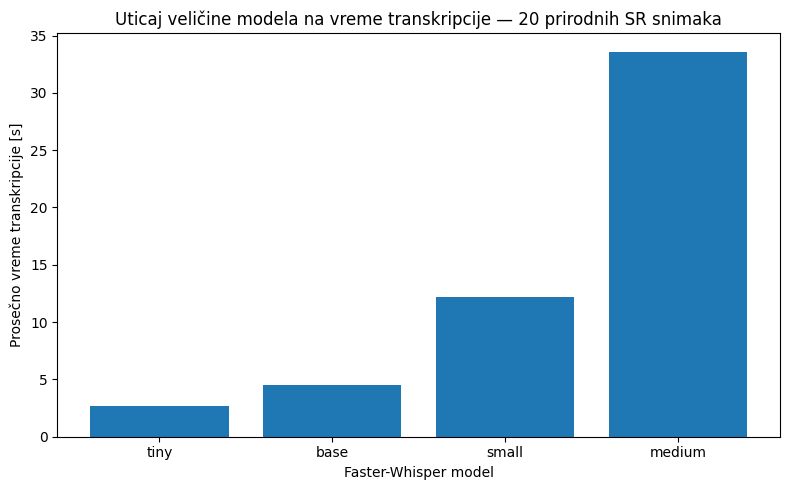

In [12]:
# ============================================================
# GRAFIK 1 - VELIČINA MODELA I VREME IZVRŠAVANJA
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    tabela_modeli["Model"],
    tabela_modeli["Prosečno vreme [s]"]
)

plt.xlabel("Faster-Whisper model")
plt.ylabel("Prosečno vreme transkripcije [s]")
plt.title("Uticaj veličine modela na vreme transkripcije — 20 prirodnih SR snimaka")
plt.tight_layout()
plt.show()

mena.


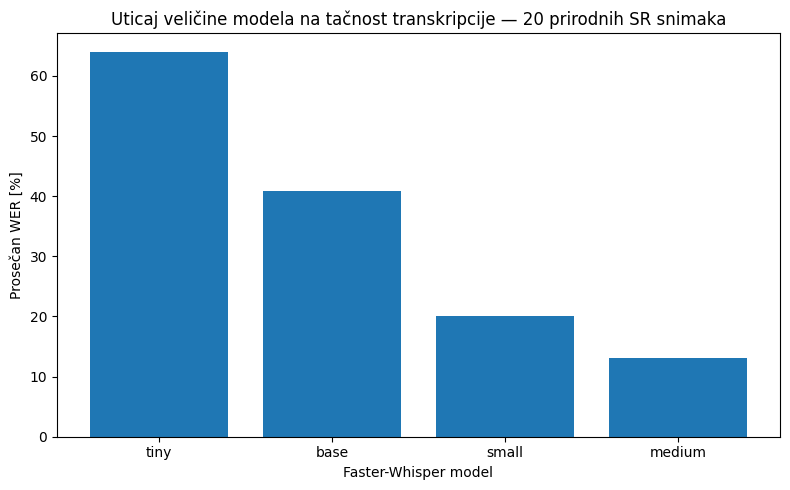

In [13]:
# ============================================================
# GRAFIK 2 - VELIČINA MODELA I WER
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    tabela_modeli["Model"],
    tabela_modeli["Prosečan WER [%]"]
)

plt.xlabel("Faster-Whisper model")
plt.ylabel("Prosečan WER [%]")
plt.title("Uticaj veličine modela na tačnost transkripcije — 20 prirodnih SR snimaka")
plt.tight_layout()
plt.show()

## Komentar vremena izvršavanja i RTF-a

Povećavanje veličine modela dovodi do značajnog povećanja vremena potrebnog za transkripciju. Ukupno vreme obrade 20 snimaka iznosilo je **52,963 s** za `tiny`, **90,377 s** za `base`, **243,875 s** za `small` i čak **671,142 s** za `medium`.

Prosečan RTF raste sa **0,0871** kod `tiny` modela na **0,1405** kod `base` i **0,3907** kod `small` modela. Sve tri konfiguracije imaju prosečan RTF značajno manji od 1, što pokazuje da na korišćenom CPU sistemu u proseku obrađuju audio brže od njegovog realnog trajanja.

Kod modela `medium` prosečan RTF raste na **1,0452**. To pokazuje da povećanje tačnosti ovog modela ima značajnu cenu u brzini izvršavanja i da `medium` na testiranom CPU sistemu više ne obezbeđuje konzistentnu obradu bržu od realnog vremena.
osek.


## Zaključak eksperimenta

Eksperiment je pokazao da veličina Faster-Whisper modela ima izražen uticaj i na kvalitet transkripcije i na brzinu izvršavanja na CPU-u.

Povećanjem modela od `tiny` do `medium`, prosečan WER smanjen je sa **63,97% na 13,14%**, dok je medijana WER-a kod najvećeg testiranog modela iznosila samo **8,17%**. Istovremeno je prosečno vreme obrade poraslo sa **2,648 s na 33,557 s**, a prosečan RTF sa **0,0871 na 1,0452**.

Model `tiny` pruža veoma brzo izvršavanje, ali je njegova tačnost na ovom skupu nedovoljna za pouzdanu transkripciju srpskog govora. `Base` predstavlja poboljšanje tačnosti uz i dalje veoma brzo izvršavanje, dok `small` ostvaruje znatno niži WER uz prosečan RTF od **0,3907**, odnosno obradu koja je i dalje značajno brža od realnog vremena. `Medium` daje najniži ukupni WER, ali uz višestruko veće vreme izvršavanja i prosečan RTF približno jednak 1.

Dobijeni rezultati pokazuju da najveći model nije automatski najpogodniji za svaku praktičnu primenu. Izbor modela treba izvršiti prema zahtevima sistema, odnosno prema tome da li je prioritet maksimalna tačnost transkripcije ili brza obrada uz ograničene računarske resurse.
